In [1]:
# Basic imports
import os
import re
import textwrap

# RAG components
from langchain_community.document_loaders import PyMuPDFLoader
from langchain_text_splitters import CharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma

# LangChain tools
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnableLambda

# LLM
from langchain_openai import ChatOpenAI

# DO NOT MODIFY THESE
from eval.eval_task1_quant import llm, eval_rag_chain_proj_query

# These are provided as reference
# You do not NEED to use these
from eval.eval_task1_quant import (
    baseline_hfe, baseline_vectorstore,
    baseline_retriever, baseline_rag_chain
)

from parser_SA import *

import json
from langchain_core.documents import Document

# General
# Functions for interacting with the operating system
import os

# Disable parallelism warnings from Hugging Face tokenizers
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# Clean print statements
import textwrap

# Get PDFs as Document object
from langchain_community.document_loaders import PyMuPDFLoader

# Recursive parsing
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Dynamic Semantic Chunking
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_experimental.text_splitter import SemanticChunker

# For setting up vectorstore
from langchain_chroma import Chroma

# Supports literal conversion
import ast

# Option for easy text cleaning
from textblob import TextBlob

# Allows for async calls to llms
import asyncio

# For comparing serial vs. async calls
import time

# Clients for access TDAC hosted models via OpenAI APIs
from openai import OpenAI, AsyncOpenAI

# To measure semantic similarity
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# For sparse retrieval
from langchain_community.retrievers import BM25Retriever

# For Cross-Encoder retrieval
from sentence_transformers import CrossEncoder

# RAG components
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma

# LangChain tools
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnableLambda

# LLM
from langchain_openai import ChatOpenAI




In [2]:
# Standard library
import json
import logging
import operator
import os
import sys
from pathlib import Path
from pprint import pprint
from types import SimpleNamespace
from typing import Annotated, List, Literal
from tqdm import tqdm
import random

# Third party
import requests
from IPython.display import Image, display
from typing_extensions import NotRequired, TypedDict

# Pydantic
from pydantic import BaseModel, Field

# OpenAI
from openai import OpenAI

# LangChain Core
from langchain_core.documents import Document
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnableLambda, RunnablePassthrough
from langchain_core.tools import tool
from langchain_core.messages import ToolMessage

# LangChain potpurri
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEndpointEmbeddings, HuggingFaceEmbeddings
from langchain_chroma import Chroma
from chromadb.utils.embedding_functions import HuggingFaceEmbeddingServer

# LangChain OpenAI
from langchain_openai import ChatOpenAI

# LangChain Community
from langchain_community.tools import DuckDuckGoSearchResults
from langchain_community.document_loaders import PyMuPDFLoader

# LangGraph
from langgraph.graph import StateGraph, END

# Add the PARENT directory (oa4910) to sys.path and load helper functions
sys.path.append(str(Path.cwd().parent))
from helper_code.rag.load_dataset import setup_embedding_function, load_db_from_dir, load_vectorstore

In [3]:
# Function to clean documents extracted from PDFs
def baseline_clean_doc(text: str) -> str:
    '''
    Function to clean PyMuPDFLoader documents created from the SRD5_OGL. 
    Contains a regex expression for a common header found in SRD5_OGL.
    '''
    HEADER = re.compile(
        r"""^
        Not\s+for\s+resale\.\s+
        Permission\s+granted\s+to\s+print\s+or\s+photocopy\s+this\s+document\s+for\s+personal\s+use\s+only\.\s+
        System\s+Reference\s+Document\s+5\.0\s*
        """,
        re.IGNORECASE | re.VERBOSE
    )

    text = text.replace("\xa0", " ")        # Normalize non-breaking spaces
    text = HEADER.sub("", text, count=1)    # Remove boilerplate header

    return text.strip()

In [4]:
# Text splitter used for baseline chunking
baseline_splitter = CharacterTextSplitter(
    separator="",
    chunk_size=3500,
    chunk_overlap=300,
)

In [5]:
# Path to documents
directory = "docs/projects/test"
proj_doc_paths = [os.path.join(directory, filename) for filename in os.listdir(directory) if filename.endswith('.pdf')]

# We will build the flat list directly
proj_docs_flat = []

for doc_path in proj_doc_paths:
    try:
        # 1. Parse the PDF using your custom logic
        boxes = FormTextExtractor(doc_path).extract_boxes()
        pds_dict = get_pds(boxes)
        
        # 2. Extract the Project ID (the top-level key) and the data payload
        project_id = list(pds_dict.keys())[0]
        project_data = pds_dict[project_id]
        
        # 3. Convert the nested dictionary into a structured string for the LLM to read.
        page_content = json.dumps(project_data, indent=2)
        
        # 4. Create the LangChain Document with ALL top section fields as metadata
        doc = Document(
            page_content=page_content,
            metadata={
                "source": doc_path,
                "project_id": project_id,
                "title": project_data.get("title"),
                "installation": project_data.get("installation"),
                "CWE": project_data.get("CWE"),
                "CCN": project_data.get("CCN"),
                "region": project_data.get("region"),
                "lead_proponent": project_data.get("lead_proponent"),
                "COCOM": project_data.get("COCOM"),
                "scope": project_data.get("scope"),
                "impact_if_not_provided": project_data.get("impact_if_not_provided")
            }
        )
        
        proj_docs_flat.append(doc)
        
    except Exception as e:
        print(f"Error processing {doc_path}: {type(e).__name__} - {e}")

# Verify
print(f'Total Documents Processed: {len(proj_docs_flat)}')

Total Documents Processed: 15


In [6]:
########## POM26 FACILITY GUIDANCE ##########
# Path to documents
directory = "docs/facilities/pom26"
fac26_doc_paths = [
    os.path.join(directory, filename) 
    for filename in os.listdir(directory) 
    if filename.endswith('.pdf')
    ]

# Extract text into documents
fac26_docs_multilevel = [
    PyMuPDFLoader(doc_path).load() 
    for doc_path in fac26_doc_paths
    ]

# Flatten docs into 1 dim list
fac26_docs_flat = [
    item 
    for sublist in fac26_docs_multilevel 
    for item in sublist
    ]

########## POM28 FACILITY GUIDANCE ##########

# Path to documents
directory = "docs/facilities/pom28"
fac28_doc_paths = [
    os.path.join(directory, filename) 
    for filename in os.listdir(directory) 
    if filename.endswith('.pdf')
    ]

# Extract text into documents
fac28_docs_multilevel = [
    PyMuPDFLoader(doc_path).load() 
    for doc_path in fac28_doc_paths
    ]

# Flatten docs into 1 dim list
fac28_docs_flat = [
    item 
    for sublist in fac28_docs_multilevel 
    for item in sublist
    ]

########## POM26 STRATEGY ##########
# Path to documents
directory = "docs/facilities/pom26"
strat26_doc_paths = [
    os.path.join(directory, filename) 
    for filename in os.listdir(directory) 
    if filename.endswith('.pdf')
    ]

# Extract text into documents
strat26_docs_multilevel = [
    PyMuPDFLoader(doc_path).load() 
    for doc_path in strat26_doc_paths
    ]

# Flatten docs into 1 dim list
strat26_docs_flat = [
    item 
    for sublist in strat26_docs_multilevel 
    for item in sublist
    ]

########## POM28 STRATEGY ##########
# Path to documents
directory = "docs/facilities/pom28"
strat28_doc_paths = [
    os.path.join(directory, filename) 
    for filename in os.listdir(directory) 
    if filename.endswith('.pdf')
    ]

# Extract text into documents
strat28_docs_multilevel = [
    PyMuPDFLoader(doc_path).load() 
    for doc_path in strat28_doc_paths
    ]

# Flatten docs into 1 dim list
strat28_docs_flat = [
    item 
    for sublist in strat28_docs_multilevel 
    for item in sublist
    ]

In [7]:
# Function to clean documents extracted from PDFs
def baseline_clean_doc(text: str) -> str:
    '''
    Function to clean PyMuPDFLoader documents created from the SRD5_OGL. 
    Contains a regex expression for a common header found in SRD5_OGL.
    '''
    HEADER = re.compile(
        r"""^
        Not\s+for\s+resale\.\s+
        Permission\s+granted\s+to\s+print\s+or\s+photocopy\s+this\s+document\s+for\s+personal\s+use\s+only\.\s+
        System\s+Reference\s+Document\s+5\.0\s*
        """,
        re.IGNORECASE | re.VERBOSE
    )

    text = text.replace("\xa0", " ")        # Normalize non-breaking spaces
    text = HEADER.sub("", text, count=1)    # Remove boilerplate header

    return text.strip()

In [8]:
# How to get a response from the LLM
response = llm.invoke("What are you?")
response.content

'I am TRACLM, a large language model designed to support the Army domain through the provision of accurate and informative responses. My development involved fine-tuning open-source, permissively licensed language models using a unique dataset comprising unclassified Army doctrine, as well as other raw and synthetically generated data from authoritative Army sources. The fine-tuning process was enabled by the computational resources available at the Naval Postgraduate School (NPS) and was overseen by The Research and Analysis Center (TRAC), a direct reporting unit to Army Futures Command (AFC). As an experimental model, I am prone to errors and may generate incorrect information, and users are advised to verify my responses and exercise caution when relying on me.'

In [9]:
# Embedding model
embed_model_name = "sentence-transformers/all-MiniLM-L6-v2"
model_kwargs = {"device": "cpu"}
encode_kwargs = {"normalize_embeddings": False}

baseline_hfe = HuggingFaceEmbeddings(
    model_name=embed_model_name,
    model_kwargs=model_kwargs,
    encode_kwargs=encode_kwargs,
)

In [10]:
# Recursive text splitting
# `chunk_size` and `chunk_overlap` are tunable hyperparameters
# `separators` can also be used to specify what to split on
recursive_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200
)

# Creates chunks from documents using the splitter
recursive_proj_docs = recursive_splitter.transform_documents(proj_docs_flat)
recursive_fac26_docs = recursive_splitter.transform_documents(fac26_docs_flat)
recursive_strat26_docs = recursive_splitter.transform_documents(strat26_docs_flat)

# Add unique chunk id as metadata
# Chromadb requires strings for metadata
# Crombadb will throw an error if id is 0
for i, chunk in enumerate(recursive_proj_docs, start=1):
    chunk.metadata['id'] = str(i)
for i, chunk in enumerate(recursive_fac26_docs, start=1):
    chunk.metadata['id'] = str(i)
for i, chunk in enumerate(recursive_strat26_docs, start=1):
    chunk.metadata['id'] = str(i)

# Create vectore store for base recursive method
# Saved locally
recursive_chunk_vectorstore_proj = Chroma.from_documents(
    documents=recursive_proj_docs, 
    embedding=baseline_hfe,
    persist_directory="databases/proj",
    ids=[doc.metadata["id"] for doc in recursive_proj_docs]
)
recursive_chunk_vectorstore_fac26 = Chroma.from_documents(
    documents=recursive_fac26_docs, 
    embedding=baseline_hfe,
    persist_directory="databases/fac26",
    ids=[doc.metadata["id"] for doc in recursive_fac26_docs]
)
recursive_chunk_vectorstore_strat26 = Chroma.from_documents(
    documents=recursive_strat26_docs, 
    embedding=baseline_hfe,
    persist_directory="databases/strat26",
    ids=[doc.metadata["id"] for doc in recursive_strat26_docs]
)


In [11]:
## GREEN ##
# No change from Lsn8 ipynb
API_KEY = "sk-UtrV9i5fFenmG6hvMss71A"
BASE_URL = "http://trac-malenia.ern.nps.edu:8080/inference/v1"

# Check the models available
model_ids = []

try:
    response = requests.get(
        f"{BASE_URL}/models",
        headers={"Authorization": f"Bearer {API_KEY}"}
    )
    response.raise_for_status()  
    info = response.json()
    
    for model in info['data']:
        model_ids.append(model['id'])
    model_id = info['data'][0]['id']
    print(f"Available Models: {model_ids}")
    print(f"\nDefault Selected Model Id: {model_id}")
except Exception as e:
    print(f"Error accessing model endpoint: {e}")

## YELLOW ##
# choose your desired model by updating model_id -- see the returned Available Models above and index based off that list
model_id = model_ids[0]
print(model_id)

# Create a model instance to use as your router -- HINT: which of the available models supports tool calling?
llm_md_tools = ChatOpenAI(
    base_url=BASE_URL,
    model=model_id,
    api_key=API_KEY,
    temperature=0,  
    name= "TRACLM-instruct" # Name the LLM for langchain
)

# test the model's responsiveness
prompt = "Briefly explain the concept of Dungeons and Dragons (D&D)?"

for chunk in llm_md_tools.stream(prompt):
    print(chunk.content, end='')

## YELLOW ## 
# Create a model instance to generate your responses, if you want to use a different one than above
# You can choose whichever model you'd like, but not all are likely to perform well for the given eval prompts
llm_gen_tools = ChatOpenAI(
    base_url=BASE_URL,
    model= model_ids[2],
    api_key=API_KEY,
    temperature=0.3,
    name="llama3-instruct"
)

# test the model's responsiveness
prompt = "Where was Donald Trump born?"
result_gen = llm_gen_tools.invoke(prompt)

print(f"General- {result_gen.content[:165]}")

Available Models: ['TRAC-MTRY/traclm-v4-7b-instruct', 'google/gemma-3-27b-it', 'casperhansen/llama-3.3-70b-instruct-awq', 'allenai/Olmo-3-7B-Instruct', 'Qwen/Qwen3-30B-A3B-Thinking-2507-FP8', 'Voxtral-Mini-3B-2507', 'Qwen/Qwen3-30B-A3B-Instruct-2507-FP8']

Default Selected Model Id: TRAC-MTRY/traclm-v4-7b-instruct
TRAC-MTRY/traclm-v4-7b-instruct
Dungeons and Dragons (D&D) is a tabletop role-playing game where players create characters and embark on adventures in a fantasy world. The game is guided by a Dungeon Master (DM), who acts as the game's storyteller and referee. Players use dice to determine the outcome of their actions and decisions, and the DM uses these rolls to create challenges and obstacles for the players to overcome. The game encourages creativity, problem-solving, and social interaction among players.General- Donald Trump, the 45th President of the United States, was born on June 14, 1946, in Queens, New York City, New York. Specifically, he was born at Jamaica Hospita

In [12]:
## GREEN ##
# Setup logging for tool creation and testing
logger = logging.getLogger("agentic_workflow")
logger.setLevel(logging.DEBUG)

# Add console handler if not already present
if not logger.handlers:
    console_handler = logging.StreamHandler()
    console_handler.setLevel(logging.DEBUG)
    formatter = logging.Formatter('%(levelname)s - %(message)s')
    console_handler.setFormatter(formatter)
    logger.addHandler(console_handler)

logger.info("Logger configured for tool creation and testing")

## GREEN ##
# create logging runnable to track router chain execution
def logging_helper(state: dict) -> dict:
    """Log internal chain steps"""
    logger.debug(f"Intermediary State: '{state}'")
    return state

r_logger = RunnableLambda( logging_helper, name= "log chain state")

INFO - Logger configured for tool creation and testing


In [13]:
proj_vectorstore_path: str = "./databases/proj"
proj_vectorstore = load_vectorstore(proj_vectorstore_path, embedding_function=baseline_hfe)

fac26_vectorstore_path: str = "./databases/fac26"
fac26_vectorstore = load_vectorstore(fac26_vectorstore_path, embedding_function=baseline_hfe)

strat26_vectorstore_path: str = "./databases/strat26"
strat26_vectorstore = load_vectorstore(strat26_vectorstore_path, embedding_function=baseline_hfe)

Loaded vectorstore with 113 documents
Loaded vectorstore with 309 documents
Loaded vectorstore with 309 documents


In [61]:
## YELLOW ##
# Provide instructions for the routing tool, and the available routes. See Lsn8 for example.
# Instructions should be something like use this vectorstore for this, use that one for that, otherwise use...
class RouteSelection(BaseModel):
    """Route selection for query processing.

    The project vectorstore contains project planning documents required for briefing a project or selectng a project for funding. 
    contains all the necessary information for projects including, but not limited to, location, price, scope, impact if not provided, region, lead proponent, etc.
    It also includes the region and lead proponent justification and scores for the main scoring categories of Mission Alignment, Readiness Support, Operational Cost, and Severity (sometimes Urgency as well).
    The facility vectorstore contains the Commander, Naval Installation Command (CNIC) guidance for how to assess a project, including the criteria for each 0-4 score in the four voting categories.
    The strategy vectorstore contains the National Security Strategy (NSS) and National Defense Strategy (NDS) applicable to the projects. 
    The facility vectorstore consists of two vectorstores - one for POM26 (fac26_vectorstore), which is the original guidance, and one for POM28 (fac28_vectorstore), which is the updated guidance.
    The strategy vectorstore consists of two vectorstores - one for POM26 (strat26_vectorstore), which is the original guidance, and one for POM28 (strat28_vectorstore), which is the updated guidance.
    Use 'proj_vectorstore' for questions about specific projects.
    Use 'fac26_vectorstore' for questions about facility criteria in POM26.
    Use 'fac28_vectorstore' for questions about facility criteria in POM28.
    Use 'strat26_vectorstore' for questions about strategy in POM26.
    Use 'strat28_vectorstore' for questions about strategy in POM28.
    Use 'websearch' for everything else.
    """
    route: Literal["proj_vectorstore", "fac26_vectorstore", "fac28_vectorstore", "strat26_vectorstore", "strat28_vectorstore", "websearch"] = Field(
        description="Selected route based on query type."
    )

@tool(args_schema=RouteSelection)
def select_route(route: str) -> str:
    """Route user queries to the appropriate source.
    The project vectorstore contains project planning documents required for briefing a project or selectng a project for funding. 
    contains all the necessary information for projects including, but not limited to, location, price, scope, impact if not provided, region, lead proponent, etc.
    It also includes the region and lead proponent justification and scores for the main scoring categories of Mission Alignment, Readiness Support, Operational Cost, and Severity (sometimes Urgency as well).
    The facility vectorstore contains the Commander, Naval Installation Command (CNIC) guidance for how to assess a project, including the criteria for each 0-4 score in the four voting categories.
    The strategy vectorstore contains the National Security Strategy (NSS) and National Defense Strategy (NDS) applicable to the projects. 
    The facility vectorstore consists of two vectorstores - one for POM26 (fac26_vectorstore), which is the original guidance, and one for POM28 (fac28_vectorstore), which is the updated guidance.
    The strategy vectorstore consists of two vectorstores - one for POM26 (strat26_vectorstore), which is the original guidance, and one for POM28 (strat28_vectorstore), which is the updated guidance.
    Use 'proj_vectorstore' for questions about specific projects.
    Use 'fac26_vectorstore' for questions about facility criteria in POM26.
    Use 'fac28_vectorstore' for questions about facility criteria in POM28.
    Use 'strat26_vectorstore' for questions about strategy in POM26.
    Use 'strat28_vectorstore' for questions about strategy in POM28.
    """
    return route

llm_router = llm_md_tools.bind_tools([select_route], tool_choice='select_route')

# Router instructions
router_prompt = ChatPromptTemplate.from_messages([
    ("system", """You are a query routing assistant. Your job is to analyze user queries and route them to the appropriate source. 

The project vectorstore contains project planning documents required for briefing a project or selectng a project for funding. 
contains all the necessary information for projects including, but not limited to, location, price, scope, impact if not provided, region, lead proponent, etc.
It also includes the region and lead proponent justification and scores for the main scoring categories of Mission Alignment, Readiness Support, Operational Cost, and Severity (sometimes Urgency as well).
The facility vectorstore contains the Commander, Naval Installation Command (CNIC) guidance for how to assess a project, including the criteria for each 0-4 score in the four voting categories.
The strategy vectorstore contains the National Security Strategy (NSS) and National Defense Strategy (NDS) applicable to the projects. 
The facility vectorstore consists of two vectorstores - one for POM26 (fac26_vectorstore), which is the original guidance, and one for POM28 (fac28_vectorstore), which is the updated guidance.
The strategy vectorstore consists of two vectorstores - one for POM26 (strat26_vectorstore), which is the original guidance, and one for POM28 (strat28_vectorstore), which is the updated guidance.

ROUTING RULES:
Route to 'proj_vectorstore' for ANY question about a specific project ID 
(e.g. P738, P222, RM16-0799, NF20-0826, ST18-1369, etc.) or project details 
like CWE, capacity ratings, scores, facility age, or lead proponent.
Route to 'fac26_vectorstore' ONLY for general POM26 facility guidance policy questions. Specifically, definitions for items on the Project Data Sheets (PDS), such as Mission Alignment, Readiness Support, Operational Cost, and Severity.

Route to 'websearch' for topics outside of military facility projects and guidance.


"""),
    ("human", "{query}")
])

# Create the router chain
router_chain = router_prompt | r_logger | llm_router

# Test -- route should = proj_vectorstore
result = router_chain.invoke("Are there any airfield projects in Italy?") # proj_vectorstore
#result = router_chain.invoke("How do players determine if a move is legal in Dungeons and Dragons?") # scen_vectorstore
#result = router_chain.invoke("Where can I buy the materials needed to play Dungeons and Dragons?") # websearch
print(result)
print(result.tool_calls[0]["args"])

content='' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 13, 'prompt_tokens': 1007, 'total_tokens': 1020, 'completion_tokens_details': None, 'prompt_tokens_details': None}, 'model_provider': 'openai', 'model_name': 'nvidia_nim/TRAC-MTRY/traclm-v4-7b-instruct', 'system_fingerprint': None, 'id': 'chatcmpl-48f4fcf5ff1947128a7ca6228d76cd02', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--019cb121-0d0a-7772-bb9c-a1c10ec06e5e-0' tool_calls=[{'name': 'select_route', 'args': {'route': 'fac26_vectorstore'}, 'id': 'chatcmpl-tool-1aadff4910294582ba7d75a7bb268684', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 1007, 'output_tokens': 13, 'total_tokens': 1020, 'input_token_details': {}, 'output_token_details': {}}
{'route': 'fac26_vectorstore'}


In [62]:
## GREEN ##
# OPTIONAL
# Check functionality of the router - first two questions should route to chars_vectorstore, next three to scen_vectorstore, and last two to websearch
test_questions = [
    "What is the CWE for P314?",
    "What is the definition for Mission Alignment?",
    "What are the pillars of the POM26 NSS and NDS?",
    "Who is Bill Belichick?",
]

logger.setLevel(logging.INFO)
results = router_chain.batch(test_questions)
for question, result in zip(test_questions, results):
    print(question, result.tool_calls[0]["args"])

What is the CWE for P314? {'route': 'proj_vectorstore'}
What is the definition for Mission Alignment? {'route': 'fac26_vectorstore'}
What are the pillars of the POM26 NSS and NDS? {'route': 'strat26_vectorstore'}
Who is Bill Belichick? {'route': 'websearch'}


In [63]:
## GREEN ##
# create websearch object
websearch = DuckDuckGoSearchResults(output_format="json",
                                    num_results=3,
                                    )

# verify websearch responsiveness
json.loads(websearch.invoke("What parts of the Constitution has the President violated?"))

[{'snippet': "Jun 25, 2025 · WASHINGTON—Donald Trump just bombed Iran. That's unconstitutional, Al Green notes. Green, the Democratic congressman from Houston, wants to impeach Trump ...",
  'title': "Trump's catalog of constitutional crimes: Long and getting longer",
  'link': 'https://www.peoplesworld.org/article/trumps-catalog-of-constitutional-crimes-long-and-getting-longer/'},
 {'snippet': 'May 20, 2025 · The Constitution does not give a president the power to violate the Constitution, create or change congressional statutes, or override US Supreme Court ...',
  'title': 'The President and Constitutional Violations: Will the Federal Courts ...',
  'link': 'https://www.americanprogress.org/article/the-president-and-constitutional-violations-will-the-federal-courts-contain-the-presidents-power-grabs/'},
 {'snippet': 'Mar 14, 2025 · The Trump Administration is breaking the law and undermining the Constitution every day by illegally stealing funds for the programs that help American f

In [64]:
## GREEN ##
class GraphState(TypedDict):
    """State for the agentic RAG workflow.

    Only 'question' is required. All other fields have defaults via init_graph_state().
    """
    question: str
    route: str | None
    generation: NotRequired[str]
    do_websearch: NotRequired[str]
    max_retries: NotRequired[int]
    gen_attempts: NotRequired[Annotated[int, operator.add]]
    documents: NotRequired[list[tuple[Document, int]]]
    k: NotRequired[int]
    dice_roll: NotRequired[int | None]
    websearch_retries: NotRequired[Annotated[int, operator.add]]  # ← ADD THIS
    max_websearch_retries: NotRequired[int]
    route_after_check: NotRequired[str]

In [65]:
## GREEN ##
def init_graph_state(state: dict) -> GraphState:
    """Initialize GraphState with defaults from partial input.
    
    Takes a dict with at minimum 'question' key and fills in defaults for other fields.
    """
    logger.info("NODE: Initialize State")
    logger.debug(f"  Input state: {state}")
    
    # Fill in defaults for any missing keys
    initialized: GraphState = {
        "question": state["question"],
        "route": state.get("route", None),
        "generation": state.get("generation", ""),
        "do_websearch": state.get("do_websearch", "no"),
        "max_retries": state.get("max_retries", 3),
        "gen_attempts": state.get("gen_attempts", 0),
        "documents": state.get("documents", []),
        "k": state.get("k", 3),
        "websearch_retries": state.get("websearch_retries", 0),
        "max_websearch_retries": state.get("max_websearch_retries", 1),
        "dice_roll": state.get("roll_dice"),
    }
    
    logger.debug(f"  Initialized state keys: {list(initialized.keys())}")
    return initialized

# Test (optional)
initialized_state = init_graph_state({"question": "Who is the US President?"})
print(f"\nInitialized state: {initialized_state}")

INFO - NODE: Initialize State



Initialized state: {'question': 'Who is the US President?', 'route': None, 'generation': '', 'do_websearch': 'no', 'max_retries': 3, 'gen_attempts': 0, 'documents': [], 'k': 3, 'websearch_retries': 0, 'max_websearch_retries': 1, 'dice_roll': None}


In [66]:
## GREEN ##
# build route question node
def route_question_node(state: dict) -> dict:
    """Determine routing decision and persist it in state"""
    logger.info("NODE: Route Question - Determining data source")

    question = state["question"]
    logger.debug(f"  Question to route: {question}")

    result = router_chain.invoke({"query": question})
    route = result.tool_calls[0]["args"]["route"]

    logger.info(f"  Routing decision: {route}")
    return {"route": route}


In [77]:
## YELLOW ##
# retrieve from vectorstore node

import re

def extract_project_id(question: str) -> str | None:
    match = re.search(r'\b(P\d{3,4}|RM\d{2}-\d{4}|NF\d{2}-\d{4}|ST\d{2}-\d{4})\b', question)
    return match.group(0) if match else None

def semantic_retrieve_w_scores(state: dict) -> dict:
    """Retrieve documents and add them to the running state."""
    
    logger.info("NODE: Semantic Retriever")
    logger.info(f"  Retriever sees route={state.get('route')!r} key={list(state.keys())}")
    query = state["question"]
    k = state.get("k", 6)

    route = state.get("route")

    # insert if/else statement here assigning which vectorstore to use
    # HINT: if route = characters, vectorstore = characters else vectorstore = scenarios
    if route == "proj_vectorstore":
        vectorstore = proj_vectorstore

    elif route == "fac26_vectorstore":
        vectorstore = fac26_vectorstore

    elif route == "fac28_vectorstore":
        vectorstore = fac28_vectorstore

    elif route == "strat26_vectorstore":
        vectorstore = strat26_vectorstore

    elif route == "strat28_vectorstore":
        vectorstore = strat28_vectorstore

    else:
        return {"documents": []} # Don't attempt to retrieve docs or score them if we are doing a web search
    
        # Extract project ID and filter if found
    project_id = extract_project_id(query)
    filter_dict = {"project_id": project_id} if project_id else None

    logger.debug(f"  Query: '{query}'")
    logger.debug(f"  Project ID filter: {project_id}")
    logger.debug(f"  Retrieving top {k} documents")
    
    docs_with_scores = vectorstore.similarity_search_with_relevance_scores(query, k=k, filter=filter_dict)
    
    logger.info(f"  Retrieved {len(docs_with_scores)} documents")
    for i, (doc, score) in enumerate(docs_with_scores):
        logger.debug(f"  Doc {i}: score={score:.3f}, source={doc.metadata.get('source', 'unknown')}, content= {doc.page_content[:50].strip()}")
    
    # Return updated state with documents added
    return {"documents": docs_with_scores}

semantic_retriever = RunnableLambda(
    semantic_retrieve_w_scores,
    name="semantic_retriever"
)

# test (optional)
results = semantic_retriever.invoke({"question": "P314", "k": 3, "route": "proj_vectorstore"})

INFO - NODE: Semantic Retriever
INFO -   Retriever sees route='proj_vectorstore' key=['question', 'k', 'route']
/var/folders/fx/40x5kxf917zbl8ml3w_3tjfr0000gn/T/ipykernel_21740/3879945342.py:48: UserWarning: Relevance scores must be between 0 and 1, got [(Document(id='39', metadata={'lead_proponent': 'CNIC N3', 'scope': 'Project constructs a new secure, flexible Mission Operation Command and Control Facility including a Maritime Operations Center (MOC), Maritime Intelligence and Operations Center (MIOC), staff administrative space, eight FlagCommander Suites and equipment space.  Project performs improvement recommendations to MOC equipment per the Integrated Nuclear Survivability & Endurability Report (INSER) Facilities Assessment.', 'CWE': 231370, 'impact_if_not_provided': 'CNE/CNA/C6F commanders will be forced to operate in an undersized, ill-configured and inadequately-capable MOC, thereby continuing to sub-optimize MOC staff effectiveness and efficiency impacting quality of staff 

In [78]:
## YELLOW ##
# dice check and roll node
def check_and_roll_dice(state: dict) -> dict:
    """Check if the question requires a dice roll and perform it if needed."""
    logger.info("NODE: Check and Roll Dice")
    
    question = state['question'].lower()
    
    # Provide a list of keywords that indicate dice rolling is needed
    dice_keywords = ["roll", "dice", "die", "20", "twenty", "sided", "sides", "rolling", "toss", "tossing", "throw", "throwing"]
    
    needs_dice = any(keyword in question for keyword in dice_keywords)
    
    if needs_dice:
        logger.info("  Dice roll detected in question")
        roll_result = roll_dice.invoke({})
        logger.info(f"  Rolled d20: {roll_result}")
        
        # Add dice roll info to state
        return {
            "dice_roll": roll_result,
        }
    else:
        logger.info("  No dice roll needed")
        return {"dice_roll": None}

In [79]:
## GREEN ##
# Websearch Node
def websearch_node(state):
    """Perform web search and format results as documents"""
    logger.info("NODE: Websearch - Performing web search")
    question = state['question']
    logger.debug(f"  Search query: {question}")

    # Perform websearch
    search_results = websearch.invoke(question)
    logger.debug(f"  Raw websearch response: {search_results[:200]}...")

    # Convert search results to document format
    import json
    results_list = json.loads(search_results)

    web_documents = []
    for result in results_list:
        doc_content = f"Title: {result['title']}\nSnippet: {result['snippet']}\nLink: {result['link']}"
        # Create a simple namespace object to mimic Document structure
        from types import SimpleNamespace
        doc = SimpleNamespace(
            page_content=doc_content,
            metadata={'source': result['link'], 'title': result['title']}
        )
        web_documents.append((doc, 1.0))  # Add dummy score to mirror 

    logger.info(f"  Websearch returned {len(web_documents)} results")
    logger.debug(f"  Result titles: {[r['title'] for r in results_list]}")
    return {"documents": web_documents}

# Test (optional)
test_state = {
    "question": "Where is the President from?"
}
result = websearch_node(test_state)

INFO - NODE: Websearch - Performing web search
INFO -   Websearch returned 3 results


In [80]:
## YELLOW ##
# Provide prompt template -- should provide some instructions for the model. Be sure to cover when to say "I don't know" and how to handle dice rolls
rag_template = (
    ChatPromptTemplate.from_messages([
        ("system", """You are a helpful assistant that answers questions based on the provided documents and any additional context passed into the prompt. \
         
         GENERAL RULES:
         1) Use the provided documents as the source of truth concerning projects, facility requirements, and strategy.
         2) If the documents do not contain the information necessary to answer the question, respond with "I don't know".
         3) Do not generate any novel information not supported by documet content or tool outputs.
         
         RULES FOR WHEN NO DOCUMENTS ARE RETRIEVED:
         1) If no documents are provided and no tool results are relevant, answer using general knowledge ONLY if the question does not have to do with Navy facilities projects.
         2) If no documents are provided, no tool results are relevant, and the question IS about navy facilities projects, respond with "I don't know".

         TOOL-AWARE BEHAVIOR RULES:
         1) You will sometimes receive tool results (either dice rolls or websearch results). If these are provided, use them in generating your response.
         2) Do NOT call tools from this prompt. Tool calls are to take place at an earlier stage of the workflow.

         """),
        ("human", """Documents:
{context}

Question: {query}
         
Instructions: You MUST respond with ONLY one of the provided answer choices exactly as written (e.g. "D) 4"). 
Do NOT make up an answer that is not one of the options. If unsure, choose the closest option.
Do not include any explanation, preamble, or additional text.

Answer based on the documents above:""")
    ])
    .with_config(run_name="RAG_Prompt_Template")
)

def generate_response(state: dict) -> dict:
    """Generate LLM response and add it to the running state."""
    logger.info("NODE: Generate Response")
    question = state['question']
    documents = state['documents']
    # dice_roll = state.get('dice_roll')
    
    logger.debug(f"  Question: {question}")
    logger.debug(f"  Using {len(documents)} documents for context")
    # logger.debug(f"  Dice roll: {dice_roll}")

    context = "\n\n---\n\n".join([doc.page_content for doc, _ in documents])
    
    # # Add dice roll information if present
    # dice_info = ""
    # if dice_roll is not None:
    #     dice_info = f"Dice Roll Result: You rolled a d20 and got {dice_roll}."

    logger.debug(f"  Context preview: {context[:100]}...")
    logger.debug(f"  Context length: {len(context)} chars")
    
    # # Create the prompt from state
    prompt = rag_template.invoke({"query": question, "context": context})
    logger.info(f"  Prompt created with {len(prompt.messages)} messages")
    logger.debug(f"  Formatted prompt messages: {[m.type for m in prompt.messages]}")
    
    # Invoke LLM and generate
    logger.info("  Invoking LLM...")
    msg = llm_gen_tools.invoke(prompt.messages)

    # Parse to string
    generation_text = getattr(msg, "content", "") or ""
    logger.info(f"  Generated response ({len(generation_text)} chars)")
    logger.debug(f"  Response preview: {generation_text[:200]}...")
    
    return {"generation": generation_text, "gen_attempts": 1}

generate_response_runnable = RunnableLambda(generate_response, name="generate_response")

# Test (optional)
test_dict= {
    "question": "test question",
    "documents": [
        [SimpleNamespace(page_content="chunk1 ..."), .5],
        [SimpleNamespace(page_content="chunk2 ..."), .5],
        [SimpleNamespace(page_content="chunk3 ..."), .5]
    ]
}

updated_state = generate_response_runnable.invoke(test_dict)

INFO - NODE: Generate Response
INFO -   Prompt created with 2 messages
INFO -   Invoking LLM...
INFO -   Generated response (12 chars)


In [81]:
## GREEN ##
# Route Question Edge
def route_question_edge(state: dict) -> str:
    """Choose graph edge based on persisted route"""
    route = state.get("route")

    logger.info(f"EDGE: route_question_edge sees route={route!r}") #keys={list(state.keys())}")
    
    if route == "websearch":
        return "websearch"
    return "retrieve"

idk_phrases = [
    "I don't know",
    "I do not know",
]

# check if generation based on retrieval contains idk
def needs_websearch_from_generation(text: str) -> bool:
    """
    Return True if generation contains any IDK phrase (substring match).
    """
    if not text:
        return True

    text_lc = text.lower()
    return any(phrase.lower() in text_lc for phrase in idk_phrases)

# check if generation based on retrieval contains idk
def check_answer_node(state: dict) -> dict:
    """
    Post-generate checker.
    Sets state['route_after_check'] to 'websearch' or 'final'
    and increments state['websearch_retries'] when routing to websearch.
    """
    
    logger.info("NODE: Checking if retrieved answer contains IDK")

    generation = state.get("generation", "")
    documents = state.get("documents", []) 

    # Use this entire commented section if you want to preview the retrieved context as part of your output
    # ---- Build context preview ----
    context_preview_parts = []
    for i, (doc, score) in enumerate(documents[:2]):  # limit to first 2 docs
        snippet = (
            doc.page_content
            .replace("\n", " ")
            .strip()[:350]
        )
        context_preview_parts.append(
            f"[doc{i} score={score:.2f}] {snippet}"
        )

    context_preview = " | ".join(context_preview_parts) or "<no documents>"

    # # ---- Generation preview ----
    gen_preview = generation.replace("\n", " ")[:120] if generation else "<empty>"

    # # ---- Side-by-side log ----
    logger.info(
        "\n"
        "  ===== RAG CHECK =====\n"
        f"  Docs count : {len(documents)}\n"
        f"  Context    : {context_preview}\n"
        f"  Generation : {gen_preview}\n"
        "  ====================="
    )
    # end of commented section for previewing retrieved context
    
    #logger.info()

    # Get current retry count (default to 0 if not set)
    retries = int(state.get("websearch_retries", 0))
    max_retries = int(state.get("max_websearch_retries", 1))

    #logger.info(f" retries={retries}, max_retries={max_retries}")
    logger.info(f"  Current retries={retries}, max_retries={max_retries}")
    #logger.debug(f" Generation preview: {generation[:100]}")

    if needs_websearch_from_generation(generation):
        
        if retries >= max_retries:
            logger.info("  IDK detected but max retries reached -> final")
            return {
                "route_after_check": "final",
            }

        logger.info(f"  IDK detected -> websearch (attempt {retries + 1}/{max_retries})")
        # Increment retry counter when routing to websearch
        return {
            "route_after_check": "websearch",
            "websearch_retries": 1,  
        }

    logger.info("  Generation is acceptable -> final")
    return {
        "route_after_check": "final",
    }

def decide_after_check(state: dict) -> str:
    return state.get("route_after_check", "final")

In [82]:
## GREEN ##
# Route Question Edge
def route_question_edge(state: dict) -> str:
    """Choose graph edge based on persisted route"""
    route = state.get("route")

    logger.info(f"EDGE: route_question_edge sees route={route!r}") #keys={list(state.keys())}")
    
    if route == "websearch":
        return "websearch"
    return "retrieve"

idk_phrases = [
    "I don't know",
    "I do not know",
]

# check if generation based on retrieval contains idk
def needs_websearch_from_generation(text: str) -> bool:
    """
    Return True if generation contains any IDK phrase (substring match).
    """
    if not text:
        return True

    text_lc = text.lower()
    return any(phrase.lower() in text_lc for phrase in idk_phrases)

# check if generation based on retrieval contains idk
def check_answer_node(state: dict) -> dict:
    """
    Post-generate checker.
    Sets state['route_after_check'] to 'websearch' or 'final'
    and increments state['websearch_retries'] when routing to websearch.
    """
    
    logger.info("NODE: Checking if retrieved answer contains IDK")

    generation = state.get("generation", "")
    documents = state.get("documents", []) 

    # Use this entire commented section if you want to preview the retrieved context as part of your output
    # ---- Build context preview ----
    context_preview_parts = []
    for i, (doc, score) in enumerate(documents[:2]):  # limit to first 2 docs
        snippet = (
            doc.page_content
            .replace("\n", " ")
            .strip()[:350]
        )
        context_preview_parts.append(
            f"[doc{i} score={score:.2f}] {snippet}"
        )

    context_preview = " | ".join(context_preview_parts) or "<no documents>"

    # # ---- Generation preview ----
    gen_preview = generation.replace("\n", " ")[:120] if generation else "<empty>"

    # # ---- Side-by-side log ----
    logger.info(
        "\n"
        "  ===== RAG CHECK =====\n"
        f"  Docs count : {len(documents)}\n"
        f"  Context    : {context_preview}\n"
        f"  Generation : {gen_preview}\n"
        "  ====================="
    )
    # end of commented section for previewing retrieved context
    
    #logger.info()

    # Get current retry count (default to 0 if not set)
    retries = int(state.get("websearch_retries", 0))
    max_retries = int(state.get("max_websearch_retries", 1))

    #logger.info(f" retries={retries}, max_retries={max_retries}")
    logger.info(f"  Current retries={retries}, max_retries={max_retries}")
    #logger.debug(f" Generation preview: {generation[:100]}")

    if needs_websearch_from_generation(generation):
        
        if retries >= max_retries:
            logger.info("  IDK detected but max retries reached -> final")
            return {
                "route_after_check": "final",
            }

        logger.info(f"  IDK detected -> websearch (attempt {retries + 1}/{max_retries})")
        # Increment retry counter when routing to websearch
        return {
            "route_after_check": "websearch",
            "websearch_retries": 1,  
        }

    logger.info("  Generation is acceptable -> final")
    return {
        "route_after_check": "final",
    }

def decide_after_check(state: dict) -> str:
    return state.get("route_after_check", "final")

In [83]:
# ## GREEN ##
# # dice edge function
# def decide_dice_or_generate(state: dict) -> str:
#     """Decide whether to check for dice rolling or go straight to generation."""
#     question = state['question'].lower()
#     dice_keywords = ["roll", "dice", "die", "20", "twenty", "sided", "sides", "rolling", "toss", "tossing", "throw", "throwing"]
#     needs_dice = any(keyword in question for keyword in dice_keywords)
    
#     if needs_dice:
#         logger.info("EDGE: Question needs dice roll -> check_dice")
#         return "check_dice"
#     else:
#         logger.info("EDGE: No dice needed -> generate")
#         return "generate"

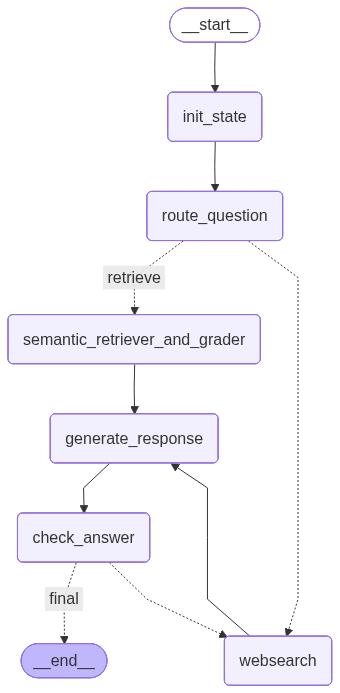

In [84]:
## YELLOW ##
# Create the graph
workflow = StateGraph(GraphState)

# Add the appropriate nodes
workflow.add_node("init_state", init_graph_state)
workflow.add_node("route_question", route_question_node)
workflow.add_node("semantic_retriever_and_grader", semantic_retrieve_w_scores)
workflow.add_node("websearch", websearch_node)
workflow.add_node("generate_response", generate_response)
workflow.add_node("check_answer", check_answer_node)

# Start -> init_state
workflow.set_entry_point("init_state")

# Add edges
# init_state -> route_question
workflow.add_edge("init_state", "route_question")

# route_question -> websearch or retrieve (conditional)
workflow.add_conditional_edges("route_question", 
                  route_question_edge,
                  {
                    "websearch": "websearch", 
                    "retrieve": "semantic_retriever_and_grader" 
                  }
                  )

# retrieve -> generate
workflow.add_edge("semantic_retriever_and_grader", "generate_response")

# websearch -> generate
workflow.add_edge("websearch", "generate_response")

# generate -> check_answer
workflow.add_edge("generate_response", "check_answer")

# check_answer -> websearch or END (conditional)
workflow.add_conditional_edges("check_answer",
                               decide_after_check,
                               {
                                   "websearch": "websearch",
                                   "final": END
                               }
                               )

# Compile the graph
app = workflow.compile()

## GREEN ##
display(Image(app.get_graph().draw_mermaid_png()))

In [85]:
question = "What is the requirement to receive a 4 in Mission Alignment in POM26?"
logger.setLevel(logging.INFO)
result = app.invoke({"question": question})

print()
print(f"=====================")
print(f"Question: {question}")
print(f"\nAnswer: {result['generation']}")
print(f"\nNumber of documents retrieved: {len(result['documents'])}")
print(f"\nGeneration attempts: {result['gen_attempts']}")

INFO - NODE: Initialize State
INFO - NODE: Route Question - Determining data source
INFO -   Routing decision: fac26_vectorstore
INFO - EDGE: route_question_edge sees route='fac26_vectorstore'
INFO - NODE: Semantic Retriever
INFO -   Retriever sees route='fac26_vectorstore' key=['question', 'route', 'generation', 'do_websearch', 'max_retries', 'gen_attempts', 'documents', 'k', 'dice_roll', 'websearch_retries', 'max_websearch_retries']
INFO -   Retrieved 3 documents
INFO - NODE: Generate Response
INFO -   Prompt created with 2 messages
INFO -   Invoking LLM...
INFO -   Generated response (12 chars)
INFO - NODE: Checking if retrieved answer contains IDK
INFO - 
  ===== RAG CHECK =====
  Docs count : 3
  Context    : [doc0 score=0.42] (9)  Facilities directly supporting Combatant Command  (COCOM) or Fleet Commander-directed operations, logistics and  operational sustainment; command, control, and communications at  DON-assigned forward operating stations; cooperative security  locations a


Question: What is the requirement to receive a 4 in Mission Alignment in POM26?

Answer: I don't know

Number of documents retrieved: 3

Generation attempts: 2


In [87]:
# In your notebook, after app is defined:
from eval.eval_task1_quant import eval_rag_chain_proj_query

# Wrap app.invoke to match the expected interface (takes string, returns string)
agent_as_chain = RunnableLambda(
    lambda question: app.invoke({"question": question, "k": 6})["generation"]
)

eval_rag_chain_proj_query(agent_as_chain)

INFO - NODE: Initialize State
INFO - NODE: Route Question - Determining data source
INFO -   Routing decision: proj_vectorstore
INFO - EDGE: route_question_edge sees route='proj_vectorstore'
INFO - NODE: Semantic Retriever
INFO -   Retriever sees route='proj_vectorstore' key=['question', 'route', 'generation', 'do_websearch', 'max_retries', 'gen_attempts', 'documents', 'k', 'dice_roll', 'websearch_retries', 'max_websearch_retries']
/var/folders/fx/40x5kxf917zbl8ml3w_3tjfr0000gn/T/ipykernel_21740/3879945342.py:48: UserWarning: Relevance scores must be between 0 and 1, got [(Document(id='15', metadata={'title': 'JEREZ GATE ECP COMPLIANCE UPGRADES', 'project_id': 'RM21-0367', 'CWE': 3188, 'CCN': 73025, 'impact_if_not_provided': 'NAVSTA Rota will not be in full compliance with Unified Facilities Criteria for entry control points and has to accept the potential risk of increased casualties due to a major event as a result of the threat changes in the European theater.', 'scope': 'Project up

Question: What is the current working estimate (CWE) for project RM21-0367, in $K? A) 5,828 B) 3,188 C) 4,684 D) 11,470 E) 28,001
Correct Response:  B) 3,188
Pipeline Response: B) 3,188



INFO -   Routing decision: proj_vectorstore
INFO - EDGE: route_question_edge sees route='proj_vectorstore'
INFO - NODE: Semantic Retriever
INFO -   Retriever sees route='proj_vectorstore' key=['question', 'route', 'generation', 'do_websearch', 'max_retries', 'gen_attempts', 'documents', 'k', 'dice_roll', 'websearch_retries', 'max_websearch_retries']
/var/folders/fx/40x5kxf917zbl8ml3w_3tjfr0000gn/T/ipykernel_21740/3879945342.py:48: UserWarning: Relevance scores must be between 0 and 1, got [(Document(id='15', metadata={'region': 'CNR EU', 'id': '15', 'title': 'JEREZ GATE ECP COMPLIANCE UPGRADES', 'COCOM': 'EUCOM', 'project_id': 'RM21-0367', 'CCN': 73025, 'lead_proponent': 'CNIC', 'scope': 'Project upgrades and repairs non-complaint aspects of the  Jerez entry control point (ECP)to meet Unified Facilities Criteria (UFC) and contend with emerging global security threats. Scope is based upon the Military Surface Deployment and Distribution Command, Transportation Engineering Activity recom

Question: What is the Overall Capacity Rating for RM21-0367? A) 80 B) 100 C) 45 D) 88 E) 65
Correct Response:  C) 45
Pipeline Response: C) 46



INFO -   Routing decision: proj_vectorstore
INFO - EDGE: route_question_edge sees route='proj_vectorstore'
INFO - NODE: Semantic Retriever
INFO -   Retriever sees route='proj_vectorstore' key=['question', 'route', 'generation', 'do_websearch', 'max_retries', 'gen_attempts', 'documents', 'k', 'dice_roll', 'websearch_retries', 'max_websearch_retries']
INFO -   Retrieved 5 documents
INFO - NODE: Generate Response
INFO -   Prompt created with 2 messages
INFO -   Invoking LLM...
INFO -   Generated response (5 chars)
INFO - NODE: Checking if retrieved answer contains IDK
INFO - 
  ===== RAG CHECK =====
  Docs count : 5
  Context    : [doc0 score=0.25] {   "title": "REPAIR UNACCOMPANIED HOUSING (UH) - BLDG 170",   "installation": "NAS SIGONELLA IT",   "CWE": 4684,   "CCN": 72111,   "region": "CNR EU",   "lead_proponent": "CNIC N9",   "COCOM": "EUCOM",   "scope": "The scope of this project is to recondition this facilities to comply with the current living standards. This project will provide 

...

Question: What is the overall capacity rating for project P736? A) 48 B) 75 C) 100 D) 120 E) 82
Correct Response:  D) 120
Pipeline Response: C) 100



INFO -   Routing decision: proj_vectorstore
INFO - EDGE: route_question_edge sees route='proj_vectorstore'
INFO - NODE: Semantic Retriever
INFO -   Retriever sees route='proj_vectorstore' key=['question', 'route', 'generation', 'do_websearch', 'max_retries', 'gen_attempts', 'documents', 'k', 'dice_roll', 'websearch_retries', 'max_websearch_retries']
INFO -   Retrieved 6 documents
INFO - NODE: Generate Response
INFO -   Prompt created with 2 messages
INFO -   Invoking LLM...
INFO -   Generated response (6 chars)
INFO - NODE: Checking if retrieved answer contains IDK
INFO - 
  ===== RAG CHECK =====
  Docs count : 6
  Context    : [doc0 score=0.37] "score": 3   },   "lead_proponent_mission_alignment": {     "description": "Supports occasional short-term transient Joint  Operations.",     "score": 1   },   "region_readiness_support": {     "description": "Fully meets BFR with a current capacity rating of 50% or less;  Project fully meets the BFR yielding a requirement of  81,694 SF by cons

Question: What is the current capacity rating (%) for the fitness facility addressed by project P577? A) 50% B) 60% C) 40% D) 70% E) 30%
Correct Response:  C) 40%
Pipeline Response: C) 40%



INFO -   Routing decision: proj_vectorstore
INFO - EDGE: route_question_edge sees route='proj_vectorstore'
INFO - NODE: Semantic Retriever
INFO -   Retriever sees route='proj_vectorstore' key=['question', 'route', 'generation', 'do_websearch', 'max_retries', 'gen_attempts', 'documents', 'k', 'dice_roll', 'websearch_retries', 'max_websearch_retries']
INFO -   Retrieved 6 documents
INFO - NODE: Generate Response
INFO -   Prompt created with 2 messages
INFO -   Invoking LLM...
INFO -   Generated response (4 chars)
INFO - NODE: Checking if retrieved answer contains IDK
INFO - 
  ===== RAG CHECK =====
  Docs count : 6
  Context    : [doc0 score=0.12] "description": "Primary mission accomplished with moderate  workarounds. Status quo requires inefficient work around to  maintain capability.",     "score": 2   },   "region_urgency_statement": {     "description": "Resourcing required in BY to meet deadlines in Existing  Force Structure Growth arriving, Homeport Relocation start as per OCR, or

Question: What is the Region Urgency score for project P577? A) 1 B) 2 C) 3 D) 4 E) 0
Correct Response:  D) 4
Pipeline Response: D) 4

Pipeline accuracy: 76.67%
